In [1]:
# ============================================================
#   Auto‑Encoder Similarity Notebook for One Shape Folder
# ============================================================

# 0️⃣ Install / import packages (versions pinned for Colab)
!pip install -q "tensorflow==2.18.0" "pandas==2.1.4" "plotly>=5.19.0,<6" pillow scikit-learn

import os, io, base64, random, math
from pathlib import Path

import numpy as np
import plotly.express as px
import tensorflow as tf
from tensorflow.keras import layers, models
from PIL import Image
from sklearn.decomposition import PCA
from IPython.display import HTML, display


In [102]:
#@title 1️⃣ Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [103]:
#@title 2️⃣ ANTI-OVERFITTING Settings
SHAPES_ROOT = "/content/drive/MyDrive/shapes"

shape_folder   = "shape6"   #@param ["shape3","shape4","shape5","shape6"]
batch_size     = 32         #@param {type:"integer"}
epochs         = 40         #@param {type:"integer"}  # REDUCED epochs
beta           = 1.0        #@param {type:"number"}   # HIGHER β for more regularization
learning_rate  = 0.0001     #@param {type:"number"}   # LOWER learning rate
latent_dim     = 48         #@param {type:"integer"}  # Medium latent space
plot_latent_2D = True       #@param {type:"boolean"}

shape_path = Path(SHAPES_ROOT) / shape_folder
assert shape_path.is_dir(), f"{shape_path} not found"

print(f"🛡️ ANTI-OVERFITTING SETTINGS:")
print(f"▶ β parameter: {beta} (strong regularization)")
print(f"▶ Latent dimensions: {latent_dim} (medium size)")
print(f"▶ Learning rate: {learning_rate} (slow learning)")
print(f"▶ Epochs: {epochs} (prevent overfitting)")

🛡️ ANTI-OVERFITTING SETTINGS:
▶ β parameter: 1.0 (strong regularization)
▶ Latent dimensions: 48 (medium size)
▶ Learning rate: 0.0001 (slow learning)
▶ Epochs: 40 (prevent overfitting)


In [104]:
#@title 3️⃣ FIXED Load images (NO pixel inversion)
def load_png_fixed(path):
    """Load without pixel inversion - stroke=white(1), background=black(0)"""
    img = Image.open(path).convert("L")
    arr = np.array(img, dtype=np.float32) / 255.0  # NO INVERSION!
    return arr[..., None]

all_pngs = sorted([p for p in shape_path.iterdir() if p.suffix.lower()==".png"])
assert all_pngs, "No PNG images found."

ref_name = f"original{shape_folder[-1]}.png"
ref_path = shape_path / ref_name
assert ref_path.exists(), f"{ref_name} missing"
drawing_paths = [p for p in all_pngs if p.name != ref_name]

print(f"▶ Loading images with CORRECT pixel values...")
ref_img = load_png_fixed(ref_path)
x_imgs = np.stack([load_png_fixed(p) for p in drawing_paths], axis=0)

print(f"✅ Loaded {len(drawing_paths)} drawings (+1 reference)")
print(f"📊 Pixel values: stroke=white(1.0), background=black(0.0)")
print(f"📐 Reference range: {ref_img.min():.3f} to {ref_img.max():.3f}")
print("Tensor shape:", x_imgs.shape)

▶ Loading images with CORRECT pixel values...
✅ Loaded 889 drawings (+1 reference)
📊 Pixel values: stroke=white(1.0), background=black(0.0)
📐 Reference range: 0.000 to 1.000
Tensor shape: (889, 200, 200, 1)


In [105]:
#@title 4️⃣ REGULARIZED Architecture (Anti-Overfitting)
import tensorflow as tf
from tensorflow.keras import layers, models

# ------------------------------------------------------------------
img_h = 200
img_w = 200
# latent_dim = 48 (medium size)
# ------------------------------------------------------------------

def build_regularized_encoder():
    """Encoder with heavy regularization to prevent overfitting"""
    inp = layers.Input(shape=(img_h, img_w, 1))

    # Simpler architecture to reduce overfitting
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.Dropout(0.25)(x)  # Early dropout
    x = layers.MaxPool2D(2)(x)                         # 100×100

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.Dropout(0.25)(x)  # Dropout after each conv block
    x = layers.MaxPool2D(2)(x)                         # 50×50

    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.Dropout(0.3)(x)   # Increasing dropout
    x = layers.MaxPool2D(2)(x)                         # 25×25

    x = layers.GlobalAveragePooling2D()(x)

    # Smaller dense layers with heavy regularization
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)   # Heavy dropout
    x = layers.BatchNormalization()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)   # More dropout

    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_logv = layers.Dense(latent_dim, name="z_logv")(x)

    return models.Model(inp, [z_mean, z_logv], name="regularized_encoder")

def build_regularized_decoder():
    """Simpler decoder to match encoder complexity"""
    dec_in = layers.Input(shape=(latent_dim,))

    y = layers.Dense(128, activation="relu")(dec_in)
    y = layers.Dropout(0.3)(y)
    y = layers.Dense(25 * 25 * 64, activation="relu")(y)
    y = layers.Reshape((25, 25, 64))(y)

    y = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(y)  # 50×50
    y = layers.Dropout(0.2)(y)
    y = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(y)  # 100×100
    y = layers.Conv2DTranspose(16, 3, strides=2, activation="relu", padding="same")(y)  # 200×200

    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(y)
    return models.Model(dec_in, out, name="regularized_decoder")

# Enhanced VAE with stronger regularization
class RegularizedVAE(tf.keras.Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta  # Higher β for more regularization

        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def reparameterize(self, z_mean, z_logv):
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_logv) * eps

    def call(self, inputs, training=None):
        z_mean, z_logv = self.encoder(inputs, training=training)
        z = self.reparameterize(z_mean, z_logv)
        reconstruction = self.decoder(z, training=training)
        return reconstruction

    def compute_loss(self, x, training=None):
        z_mean, z_logv = self.encoder(x, training=training)
        z = self.reparameterize(z_mean, z_logv)
        reconstruction = self.decoder(z, training=training)

        # Reconstruction loss
        recon_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(x, reconstruction)
        ) * (img_h * img_w)

        # KL divergence loss (stronger regularization)
        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_logv - tf.square(z_mean) - tf.exp(z_logv)
        )

        # Balanced loss with regularization
        total_loss = recon_loss + self.beta * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self.compute_loss(x, training=True)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        total_loss, recon_loss, kl_loss = self.compute_loss(x, training=False)

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# Build the regularized VAE
encoder = build_regularized_encoder()
decoder = build_regularized_decoder()
vae = RegularizedVAE(encoder, decoder, beta=beta)

# Add early stopping and learning rate scheduling
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Slower optimizer with weight decay
optimizer = tf.keras.optimizers.Adam(
    learning_rate=learning_rate,
    weight_decay=1e-4  # L2 regularization
)
vae.compile(optimizer=optimizer, loss=lambda y_true, y_pred: 0.0)

encoder.summary()
print(f"\n✅ Regularized VAE built")
print(f"📐 Latent space: {latent_dim}D (medium size)")
print(f"🎛️ β = {beta} (strong regularization)")
print(f"🛡️ Heavy dropout + batch norm + weight decay")
print(f"🚀 Anti-overfitting architecture ready!")

# Add callbacks for training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

print(f"\n📋 Training callbacks:")
print(f"• Early stopping: patience=10")
print(f"• Learning rate reduction: factor=0.5, patience=5")

Model: "regularized_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_30      │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_72 (Conv2D)  │ (None, 200, 200,  │        320 │ input_layer_30[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 200, 200,  │          0 │ conv2d_72[0][0]   │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_35    │ (None, 100, 100,  │          0 │ dropout_10[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_73 (Conv2D)  │ (None, 100, 100,  │     18,496 │ max_pooling2d_35… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 100, 100,  │          0 │ conv2d_73[0][0]   │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_36    │ (None, 50, 50,    │          0 │ dropout_11[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_74 (Conv2D)  │ (None, 50, 50,    │     73,856 │ max_pooling2d_36… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 50, 50,    │          0 │ conv2d_74[0][0]   │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_37    │ (None, 25, 25,    │          0 │ dropout_12[0][0]  │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_37… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 256)       │     33,024 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 256)       │          0 │ dense_24[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dropout_13[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 128)       │     32,896 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 128)       │          0 │ dense_25[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 48)        │      6,192 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_logv (Dense)      │ (None, 48)        │      6,192 │ dropout_14[0][0]

 Total params: 172,000 (671.88 KB)

 Trainable params: 171,488 (669.88 KB)

 Non-trainable params: 512 (2.00 KB)


✅ Regularized VAE built
📐 Latent space: 48D (medium size)
🎛️ β = 1.0 (strong regularization)
🛡️ Heavy dropout + batch norm + weight decay
🚀 Anti-overfitting architecture ready!

📋 Training callbacks:
• Early stopping: patience=10
• Learning rate reduction: factor=0.5, patience=5


In [106]:
#@title 5️⃣ Train Regularized VAE
history = vae.fit(
    x_imgs, x_imgs,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.2,
    verbose=2,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/40
23/23 - 24s - 1s/step - kl_loss: 0.3132 - loss: 27474.8281 - reconstruction_loss: 27474.5195 - val_kl_loss: 5.7720e-04 - val_loss: 27220.6934 - val_reconstruction_loss: 27220.6934 - learning_rate: 1.0000e-04
Epoch 2/40
23/23 - 0s - 21ms/step - kl_loss: 0.6556 - loss: 25393.4707 - reconstruction_loss: 25392.8125 - val_kl_loss: 0.0044 - val_loss: 24343.0234 - val_reconstruction_loss: 24343.0215 - learning_rate: 1.0000e-04
Epoch 3/40
23/23 - 0s - 20ms/step - kl_loss: 1.0200 - loss: 15347.4102 - reconstruction_loss: 15346.3926 - val_kl_loss: 0.0178 - val_loss: 13545.0146 - val_reconstruction_loss: 13544.9971 - learning_rate: 1.0000e-04
Epoch 4/40
23/23 - 0s - 20ms/step - kl_loss: 1.2499 - loss: 6270.5073 - reconstruction_loss: 6269.2573 - val_kl_loss: 0.0145 - val_loss: 7877.7227 - val_reconstruction_loss: 7877.7085 - learning_rate: 1.0000e-04
Epoch 5/40
23/23 - 0s - 20ms/step - kl_loss: 1.3050 - loss: 5284.1167 - reconstruction_loss: 5282.8115 - val_kl_loss: 0.0053 - val_loss: 

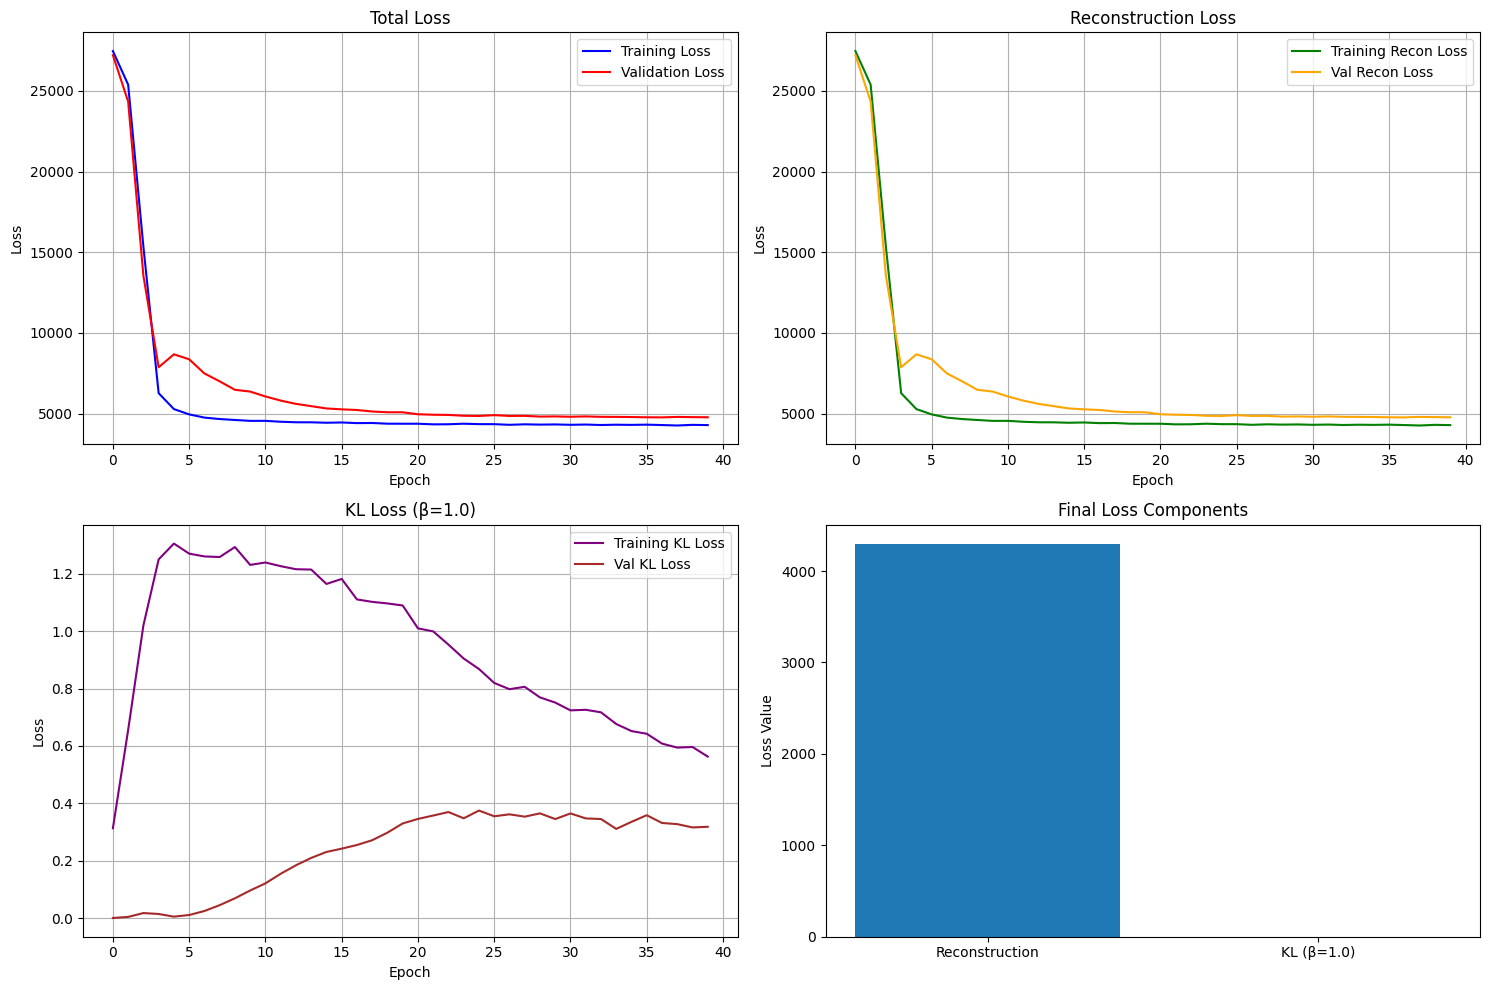


📊 Loss Analysis:
   • Final reconstruction loss: 4290.94
   • Final KL loss: 0.56
   • Final weighted KL loss (β×KL): 0.56
   • Reconstruction vs KL ratio: 7622.93


In [107]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot total loss
axes[0,0].plot(history.history['loss'], label='Training Loss', color='blue')
axes[0,0].plot(history.history['val_loss'], label='Validation Loss', color='red')
axes[0,0].set_title('Total Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True)

# Plot reconstruction loss
axes[0,1].plot(history.history['reconstruction_loss'], label='Training Recon Loss', color='green')
axes[0,1].plot(history.history['val_reconstruction_loss'], label='Val Recon Loss', color='orange')
axes[0,1].set_title('Reconstruction Loss')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()
axes[0,1].grid(True)

# Plot KL loss
axes[1,0].plot(history.history['kl_loss'], label='Training KL Loss', color='purple')
axes[1,0].plot(history.history['val_kl_loss'], label='Val KL Loss', color='brown')
axes[1,0].set_title(f'KL Loss (β={beta})')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()
axes[1,0].grid(True)

# Plot loss ratio
recon_final = history.history['reconstruction_loss'][-1]
kl_final = history.history['kl_loss'][-1]
axes[1,1].bar(['Reconstruction', f'KL (β={beta})'], [recon_final, beta * kl_final])
axes[1,1].set_title('Final Loss Components')
axes[1,1].set_ylabel('Loss Value')

plt.tight_layout()
plt.show()

print(f"\n📊 Loss Analysis:")
print(f"   • Final reconstruction loss: {recon_final:.2f}")
print(f"   • Final KL loss: {kl_final:.2f}")
print(f"   • Final weighted KL loss (β×KL): {beta * kl_final:.2f}")
print(f"   • Reconstruction vs KL ratio: {recon_final/(beta * kl_final):.2f}")

In [108]:
#@title 6️⃣ ENHANCED Similarity Analysis with Better Metrics
print("🔍 Computing enhanced similarity analysis...")

# Get embeddings
latent_ref = encoder(np.expand_dims(ref_img, 0))[0].numpy().reshape(-1)
latent_draws = encoder.predict(x_imgs, batch_size=batch_size)[0].reshape(len(x_imgs), -1)

print(f"✅ Latent shapes: ref={latent_ref.shape}, draws={latent_draws.shape}")

# Use multiple distance metrics for better discrimination
print("🧮 Computing multiple distance metrics...")

# 1. Euclidean distance (L2 norm)
euclidean_dists = np.linalg.norm(latent_draws - latent_ref, axis=1)

# 2. Manhattan distance (L1 norm) - sometimes better for sparse features
manhattan_dists = np.sum(np.abs(latent_draws - latent_ref), axis=1)

# 3. Cosine distance
cosine_sims = np.array([
    np.dot(latent_ref, draw) / (np.linalg.norm(latent_ref) * np.linalg.norm(draw))
    for draw in latent_draws
])
cosine_dists = 1 - cosine_sims

# 4. Weighted combination (emphasizes larger differences)
weighted_dists = euclidean_dists + 0.5 * manhattan_dists

# Test which metric gives best discrimination
print(f"\n📊 DISCRIMINATION ANALYSIS:")
print(f"Euclidean distance range:  {np.min(euclidean_dists):.6f} - {np.max(euclidean_dists):.6f}")
print(f"Manhattan distance range:  {np.min(manhattan_dists):.6f} - {np.max(manhattan_dists):.6f}")
print(f"Cosine distance range:     {np.min(cosine_dists):.6f} - {np.max(cosine_dists):.6f}")
print(f"Weighted distance range:   {np.min(weighted_dists):.6f} - {np.max(weighted_dists):.6f}")

# Choose the metric with best discrimination (largest range)
ranges = {
    'euclidean': np.max(euclidean_dists) - np.min(euclidean_dists),
    'manhattan': np.max(manhattan_dists) - np.min(manhattan_dists),
    'cosine': np.max(cosine_dists) - np.min(cosine_dists),
    'weighted': np.max(weighted_dists) - np.min(weighted_dists)
}

best_metric = max(ranges, key=ranges.get)
print(f"\n🏆 Best discrimination metric: {best_metric} (range: {ranges[best_metric]:.6f})")

# Use the best metric for final ranking
if best_metric == 'euclidean':
    final_dists = euclidean_dists
elif best_metric == 'manhattan':
    final_dists = manhattan_dists
elif best_metric == 'cosine':
    final_dists = cosine_dists
else:
    final_dists = weighted_dists

# Sort by distance (ascending - lower is more similar)
order = np.argsort(final_dists)
sorted_paths = [drawing_paths[i] for i in order]
sorted_dists = final_dists[order]

print(f"\n🎯 ENHANCED SIMILARITY RESULTS ({best_metric} distance):")
print("=" * 60)
print("🏆 Top 15 Most Similar Shapes:")
for i, (path, dist) in enumerate(zip(sorted_paths[:15], sorted_dists[:15])):
    print(f"{i+1:2d}. {path.name:<15} | Distance: {dist:.6f}")

print(f"\n📊 Final Distance Statistics:")
print(f"Mean: {np.mean(final_dists):.6f}")
print(f"Std:  {np.std(final_dists):.6f}")
print(f"Min:  {np.min(final_dists):.6f}")
print(f"Max:  {np.max(final_dists):.6f}")
print(f"Range: {ranges[best_metric]:.6f}")

# Discrimination quality check
if ranges[best_metric] > 0.01:
    print("✅ Good discrimination - meaningful distance variations!")
elif ranges[best_metric] > 0.001:
    print("⚠️  Moderate discrimination - some variation but could be better")
else:
    print("❌ Poor discrimination - distances too similar, need more training")

# Store for compatibility
dists = final_dists

🔍 Computing enhanced similarity analysis...
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step
✅ Latent shapes: ref=(48,), draws=(889, 48)
🧮 Computing multiple distance metrics...

📊 DISCRIMINATION ANALYSIS:
Euclidean distance range:  0.050692 - 1.189281
Manhattan distance range:  0.275093 - 6.753687
Cosine distance range:     0.000049 - 0.017714
Weighted distance range:   0.188239 - 4.566124

🏆 Best discrimination metric: manhattan (range: 6.478593)

🎯 ENHANCED SIMILARITY RESULTS (manhattan distance):
🏆 Top 15 Most Similar Shapes:
 1. 7768.png        | Distance: 0.275093
 2. 10921.png       | Distance: 0.510595
 3. 7580.png        | Distance: 0.516361
 4. 7601.png        | Distance: 0.539234
 5. 7766.png        | Distance: 0.611835
 6. 10073.png       | Distance: 0.622723
 7. 7752.png        | Distance: 0.624155
 8. 7628.png        | Distance: 0.646006
 9. 11015.png       | Distance: 0.665603
10. 10240.png       | Distance: 0.671018
11. 10316.png       | Distance: 0.678515
12. 7574.png        | 

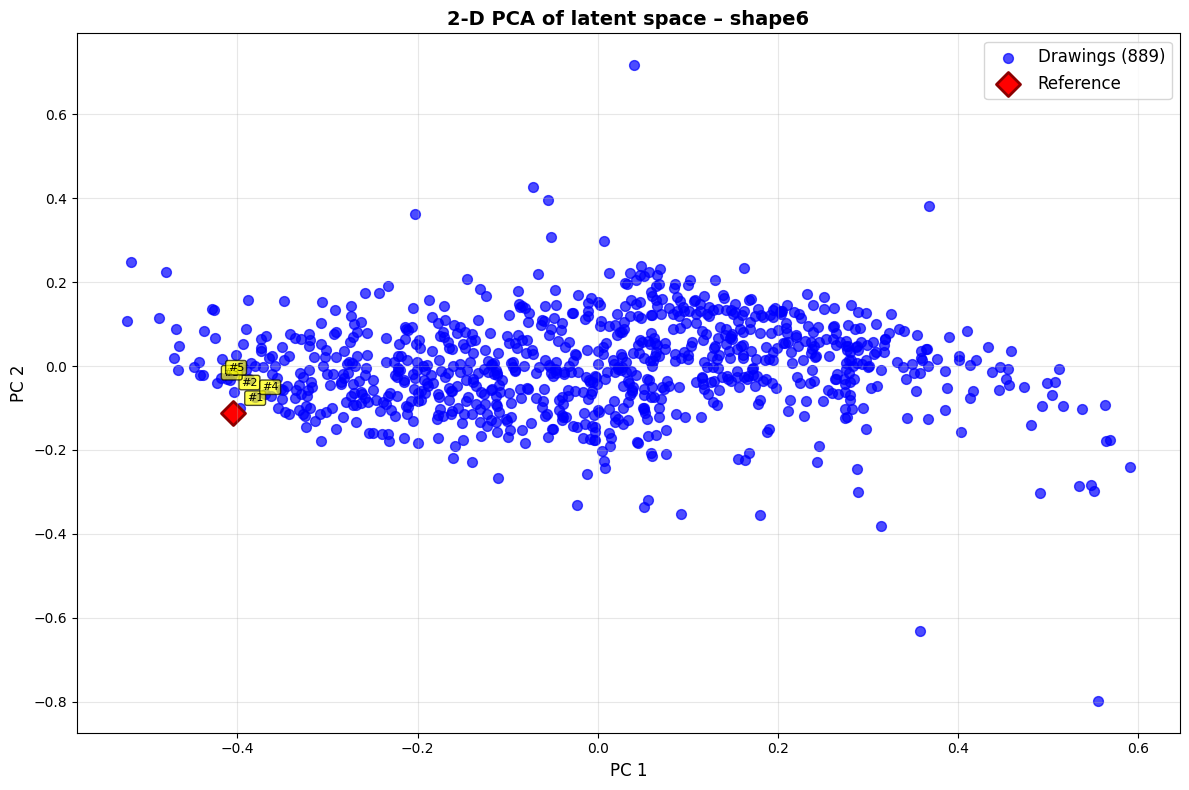

🖼️ IMAGE BROWSER:
Reference Image:


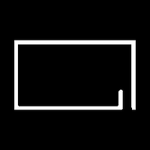


🎯 Top 10 Most Similar Drawings (out of 889):

#1: 7768.png (Distance: 0.2751)


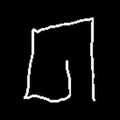


#2: 10921.png (Distance: 0.5106)


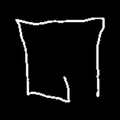


#3: 7580.png (Distance: 0.5164)


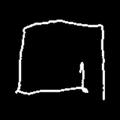


#4: 7601.png (Distance: 0.5392)


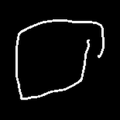


#5: 7766.png (Distance: 0.6118)


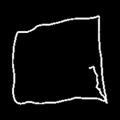


#6: 10073.png (Distance: 0.6227)


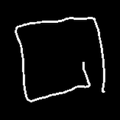


#7: 7752.png (Distance: 0.6242)


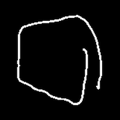


#8: 7628.png (Distance: 0.6460)


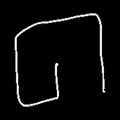


#9: 11015.png (Distance: 0.6656)


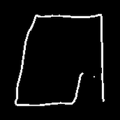


#10: 10240.png (Distance: 0.6710)


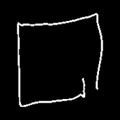


📈 SIMILARITY STATISTICS:
Mean distance: 2.7952
Std distance: 1.0804
Min distance: 0.2751
Max distance: 6.7537
Median distance: 2.8194


In [109]:
#@title 7
# Simple matplotlib version (always works in Colab)
if plot_latent_2D:
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA
    from IPython.display import display

    # ---------- reduce to 2‑D ----------
    all_lat = np.vstack([latent_ref.reshape(1, -1), latent_draws])
    lat2    = PCA(n_components=2).fit_transform(all_lat)
    xs, ys  = lat2[:, 0], lat2[:, 1]

    # Create matplotlib plot
    plt.figure(figsize=(12, 8))

    # Plot drawings
    plt.scatter(xs[1:], ys[1:], c='blue', s=50, alpha=0.7, label=f'Drawings ({len(drawing_paths)})')

    # Plot reference
    plt.scatter(xs[0], ys[0], c='red', s=150, marker='D', label='Reference', edgecolors='darkred', linewidth=2)

    # Customize plot
    plt.xlabel('PC 1', fontsize=12)
    plt.ylabel('PC 2', fontsize=12)
    plt.title(f'2-D PCA of latent space – {shape_folder}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)

    # Add some annotations for closest points
    closest_indices = np.argsort(dists)[:5]
    for i, idx in enumerate(closest_indices):
        plt.annotate(f'#{i+1}',
                    (xs[idx+1], ys[idx+1]),
                    xytext=(5, 5),
                    textcoords='offset points',
                    fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7))

    plt.tight_layout()
    plt.show()

    # Create a simple image browser
    print("🖼️ IMAGE BROWSER:")
    print("Reference Image:")
    ref_img_pil = Image.open(ref_path).convert("RGB").resize((150, 150))
    display(ref_img_pil)

    print(f"\n🎯 Top 10 Most Similar Drawings (out of {len(drawing_paths)}):")
    for i, (path, dist) in enumerate(zip(sorted_paths[:10], sorted_dists[:10])):
        print(f"\n#{i+1}: {path.name} (Distance: {dist:.4f})")
        img_pil = Image.open(path).convert("RGB").resize((120, 120))
        display(img_pil)

    # Show some statistics
    print(f"\n📈 SIMILARITY STATISTICS:")
    print(f"Mean distance: {np.mean(dists):.4f}")
    print(f"Std distance: {np.std(dists):.4f}")
    print(f"Min distance: {np.min(dists):.4f}")
    print(f"Max distance: {np.max(dists):.4f}")
    print(f"Median distance: {np.median(dists):.4f}")

▶ HTML gallery written to: /content/drive/MyDrive/shapes/shape6/shape6_vae_similarity.html



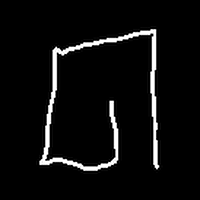
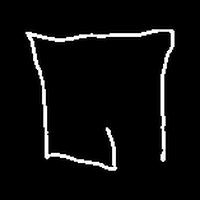
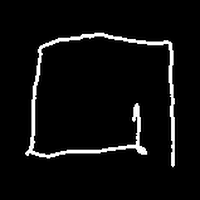
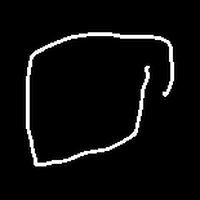
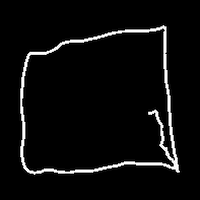
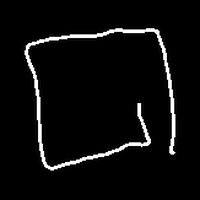
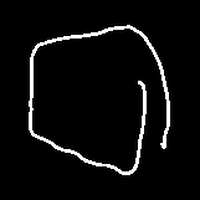
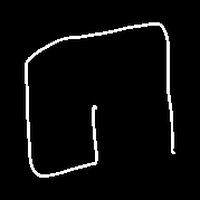
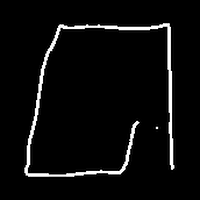
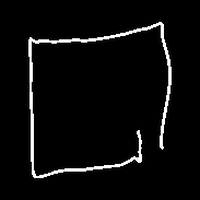
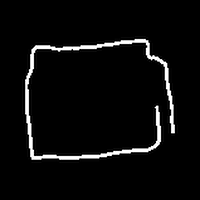
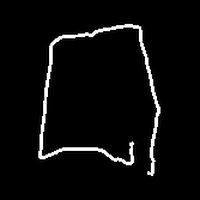
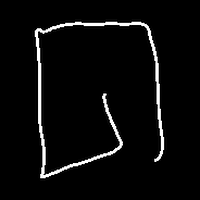
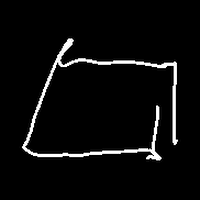
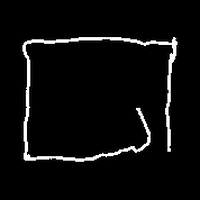
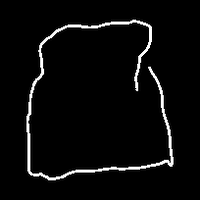
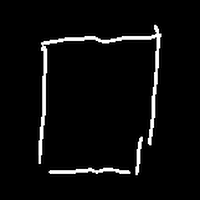
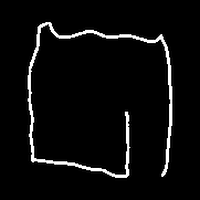
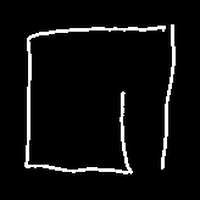
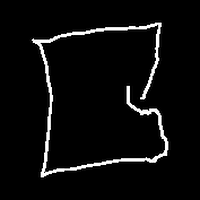
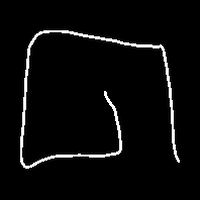
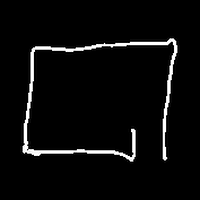
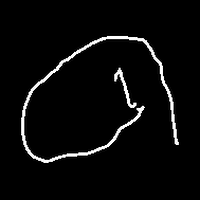
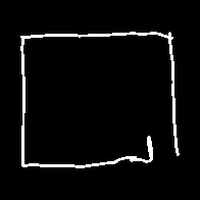
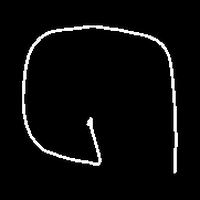
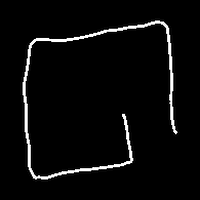
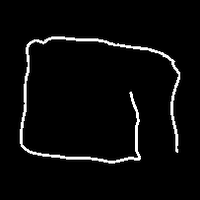
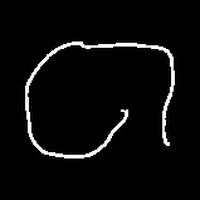

In [110]:

#@title 8️⃣ Create ordered HTML gallery (10 images per row)
html_rows = []
for i, (p,d) in enumerate(zip(sorted_paths, sorted_dists)):
    if i % 10 == 0:
        html_rows.append("<tr>")
    with open(p,'rb') as f: b64 = base64.b64encode(f.read()).decode()
    html_rows.append(
        f"<td style='text-align:center;font-size:10px'>"
        f"<img src='data:image/png;base64,{b64}' width='96'><br>"
        f"{p.name}<br>dist={d:.4f}</td>"
    )
    if i % 10 == 9:
        html_rows.append("</tr>")
if not html_rows[-1].startswith("</tr>"):
    html_rows.append("</tr>")

html_page = f"""
<html><head><meta charset='utf-8'>
<title>{shape_folder} – similarity</title></head>
<body>
<h2>Similarity ranking – {shape_folder}</h2>
<table border=0 cellspacing=4 cellpadding=4>
{''.join(html_rows)}
</table></body></html>
"""

out_path = shape_path / f"{shape_folder}_vae_similarity.html"
with open(out_path,"w") as f: f.write(html_page)
print("▶ HTML gallery written to:", out_path)

display(HTML("<h4>Preview first 30 entries</h4>"+''.join(html_rows[:33])))



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


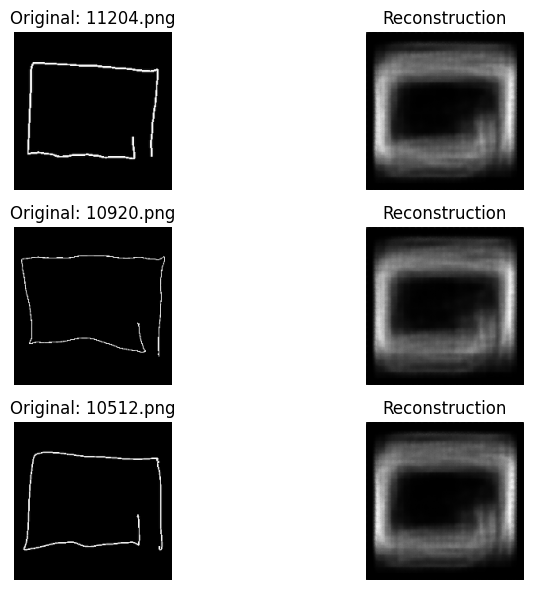

In [111]:
#@title 9️⃣ Reconstruction demo – 3 random drawings
sample_idx = np.random.choice(len(drawing_paths), 3, replace=False)
recons = vae.predict(x_imgs[sample_idx], batch_size=3)

import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
for i, idx in enumerate(sample_idx):
    # original
    plt.subplot(3,2,2*i+1)
    plt.imshow(x_imgs[idx].squeeze(), cmap='gray')
    plt.axis('off'); plt.title(f"Original: {drawing_paths[idx].name}")
    # reconstruction
    plt.subplot(3,2,2*i+2)
    plt.imshow(recons[i].squeeze(), cmap='gray')
    plt.axis('off'); plt.title("Reconstruction")
plt.tight_layout(); plt.show()
